# Multimodality landscape features

Illustrates MOLA's **multimodality** landscape features (paper §4.1.2, Table 1). Each section pairs a feature's definition with a small, real, *executed* example built on `mola`'s own code.

Built incrementally — one section is added per feature, in the same commit that implements it (see `CLAUDE.md`'s "Feature implementation matrix"). As of this notebook: `plo_n`, `plo_dist_avg`, `plo_dist_max`, `nd_per_plo`.

## `plo_n`, `plo_dist_avg`, `plo_dist_max`, `nd_per_plo` — Pareto local optima

> "a Pareto local optimum (plo) [is a] sampled solution for which there does not exist any dominating neighbour" (§4.1.2)

Reuses `mola.dominance` — a solution is a PLO iff its `dominating` count is zero. This is a genuinely different set from the non-dominated front: a solution can be **globally dominated** yet still a PLO, if the specific neighbour(s) that would dominate it happen not to be among its `k` nearest. The two plots below make the difference visible on the same toy sample. `plo_dist_avg`/`plo_dist_max` are the average/maximum pairwise variable-space distance restricted to the PLO subset — same normalization convention as every other `*_AVG`/`*_MAX` distance feature. `nd_per_plo = nd_n / plo_n` (Table 1's own formula) is always ≤ 1, since every non-dominated solution is trivially also a PLO.

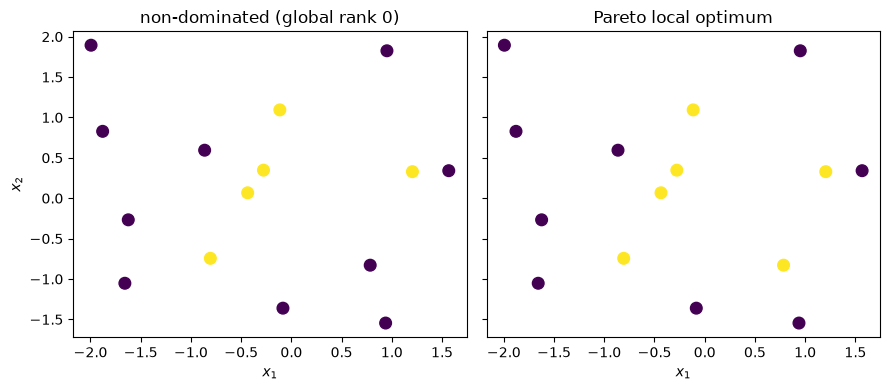

nd_n         = 0.333
plo_n        = 0.400
nd_per_plo   = 0.833


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mola.distance import build_neighbourhood
from mola.dominance import neighbourhood_dominance
from mola.features import nd_n, nd_per_plo, plo_dist_avg, plo_dist_max, plo_n
from mola.normalization import build_normalizers
from mola.ranking import rank_solutions

# Same toy bi-objective problem as the evolvability notebook: two spheres centred at
# (1, 1) and (-1, -1), so variable-space location has real structure in objective space.
mm_rng = np.random.default_rng(seed=3)
variables = mm_rng.uniform(low=-2.0, high=2.0, size=(15, 2))
objectives = np.column_stack(
    [
        ((variables - 1.0) ** 2).sum(axis=1),
        ((variables + 1.0) ** 2).sum(axis=1),
    ]
)

neighbourhood = build_neighbourhood(variables, neighbours=variables.shape[1])
ranking = rank_solutions(objectives)
dominance = neighbourhood_dominance(objectives, neighbourhood)
is_plo = dominance.dominating == 0

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
axes[0].scatter(variables[:, 0], variables[:, 1], c=(ranking.rank == 0), s=70)
axes[0].set_title("non-dominated (global rank 0)")
axes[1].scatter(variables[:, 0], variables[:, 1], c=is_plo, s=70)
axes[1].set_title("Pareto local optimum")
for ax in axes:
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.tight_layout()
plt.show()

print(f"nd_n         = {nd_n(ranking):.3f}")
print(f"plo_n        = {plo_n(dominance):.3f}")
print(f"nd_per_plo   = {nd_per_plo(ranking, dominance):.3f}")

In [2]:
normalizer = build_normalizers(variables, objectives).variable_space

print(f"plo_dist_avg = {plo_dist_avg(variables, dominance, normalizer):.3f}")
print(f"plo_dist_max = {plo_dist_max(variables, dominance):.3f}")

plo_dist_avg = 0.260
plo_dist_max = 2.280


## `slo_n`, `slo_dist_avg`, `slo_dist_max` — single-objective local optima

> "a single-objective local optimum (slo) [is a] solution with no improving neighbour for a given objective" (§4.1.2)

Inherently per-objective, unlike `plo` above: a solution is scored separately against each objective, so it can be a local optimum for $f_1$ without being one for $f_2$. The two panels below make that visible on the same toy sample. `slo_n`, `slo_dist_avg`, and `slo_dist_max` are each the *mean, across objectives*, of that objective's own proportion / normalized average distance / raw maximum distance among its local optima (Design decisions, judgment call: Table 1 doesn't restate "per objective" for the distance rows, but introduces no alternative either).

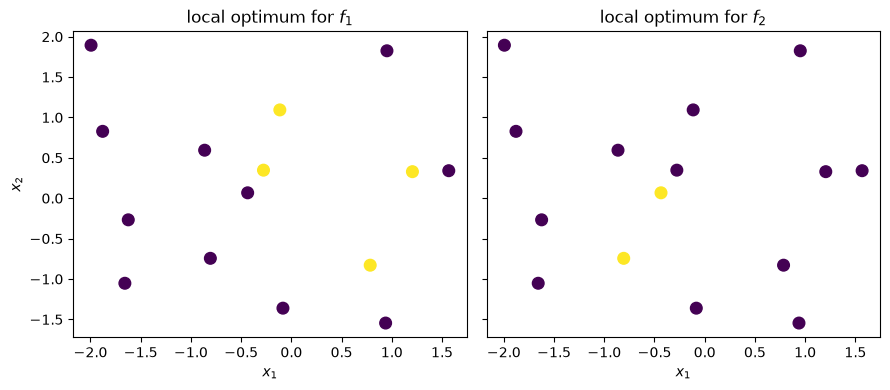

slo_n        = 0.200
slo_dist_avg = 0.203
slo_dist_max = 1.507


In [3]:
from mola.features import slo_dist_avg, slo_dist_max, slo_n
from mola.multimodality import single_objective_local_optima

slo_mask = single_objective_local_optima(objectives, neighbourhood)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for m, ax in enumerate(axes):
    ax.scatter(variables[:, 0], variables[:, 1], c=slo_mask[:, m], s=70)
    ax.set_title(f"local optimum for $f_{m + 1}$")
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.tight_layout()
plt.show()

print(f"slo_n        = {slo_n(objectives, neighbourhood):.3f}")
print(f"slo_dist_avg = {slo_dist_avg(variables, objectives, neighbourhood, normalizer):.3f}")
print(f"slo_dist_max = {slo_dist_max(variables, objectives, neighbourhood):.3f}")

## `length_aws`, `eval_aws` — the multi-objective adaptive walk

> "the neighbourhood is explored from the closest to the furthest neighbour... and the first dominating neighbour is accepted at each step" (§4.1.2)

The one genuinely new piece of simulation in the whole feature set: from a starting solution, repeatedly move to the first (closest) neighbour that dominates the current one, until none does -- the walk has reached a Pareto local optimum. `eval_aws` counts neighbours *inspected*, not real evaluations -- the paper is explicit the walk runs entirely over the precomputed neighbourhood graph. MOLA averages over `min(30, n)` independent walks from distinct random starting points; with `n=15` here, that means every solution gets used as a starting point exactly once.

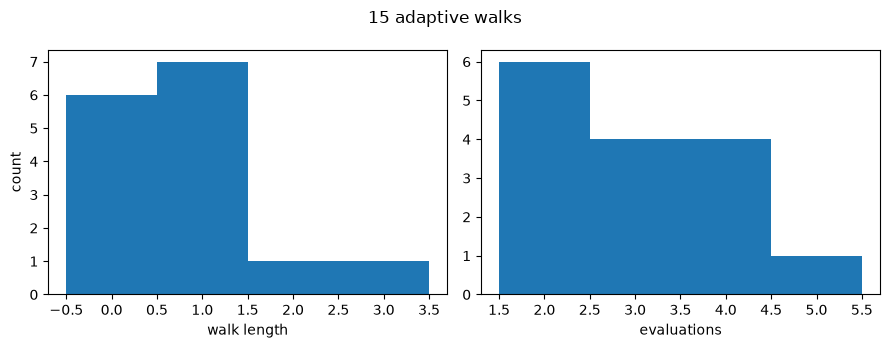

length_aws = 0.800
eval_aws   = 3.000


In [4]:
from mola.features import eval_aws, length_aws
from mola.multimodality import adaptive_walks

walks = adaptive_walks(objectives, neighbourhood, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(walks.lengths, bins=range(walks.lengths.max() + 2), align="left")
axes[0].set_xlabel("walk length")
axes[0].set_ylabel("count")
axes[1].hist(
    walks.evaluations,
    bins=range(walks.evaluations.min(), walks.evaluations.max() + 2),
    align="left",
)
axes[1].set_xlabel("evaluations")
fig.suptitle(f"{walks.lengths.size} adaptive walks")
fig.tight_layout()
plt.show()

print(f"length_aws = {length_aws(walks):.3f}")
print(f"eval_aws   = {eval_aws(walks):.3f}")